# UPPP 214 Week 9: Regression Models

<a target="_blank" href="https://colab.research.google.com/github/knaaptime/uppp214-winter26-assn/blob/main/week9/hedonic_model.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import statsmodels.formula.api as smf
from fsspec import filesystem

fs = filesystem('https')

In [2]:
balt_sales = gpd.read_parquet("https://github.com/oturns/example_datasets/raw/refs/heads/main/parcels/balt_parcels.pq", filesystem=fs)

In [3]:
acs = gpd.read_parquet("s3://spatial-ucr/census/acs/acs_2018_tract.parquet")
acs = acs[acs.index.str.startswith('24510')]

In [4]:
acs

,n_mexican_pop,n_cuban_pop,n_puerto_rican_pop,n_russian_pop,n_italian_pop,n_german_pop,n_irish_pop,n_scandaniavian_pop,n_foreign_born_pop,n_recent_immigrant_pop,...,p_veterans,p_poverty_rate,p_poverty_rate_over_65,p_poverty_rate_children,p_poverty_rate_white,p_poverty_rate_black,p_poverty_rate_hispanic,p_poverty_rate_native,p_poverty_rate_asian,geometry
GEOID,,,,,,,,,,,,,,,,,,,,,
24510250101,18.0,0.0,6.0,0.0,0.0,54.0,16.0,0.0,154.0,106.0,...,5.276498,17.891524,0.680911,3.780230,1.033106,13.266025,0.000000,0.0,0.0,"MULTIPOLYGON (((-76.71098 39.27792, -76.71071 ..."
24510250102,0.0,0.0,5.0,0.0,3.0,19.0,0.0,0.0,147.0,18.0,...,5.160692,16.131026,2.379481,3.368356,0.370828,15.574784,0.154512,0.0,0.0,"MULTIPOLYGON (((-76.69576 39.27784, -76.69572 ..."
24510250103,18.0,14.0,20.0,0.0,41.0,164.0,103.0,0.0,143.0,56.0,...,8.853709,20.382362,5.797101,0.462535,9.466543,9.312365,1.048412,0.0,0.0,"MULTIPOLYGON (((-76.69741 39.27239, -76.696 39..."
24510250203,6.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,153.0,37.0,...,6.825076,19.059656,1.718908,3.538928,3.993933,15.065723,0.000000,0.0,0.0,"MULTIPOLYGON (((-76.62527 39.24907, -76.62521 ..."
24510250204,49.0,0.0,0.0,0.0,0.0,0.0,35.0,0.0,56.0,16.0,...,2.758783,60.080170,2.664466,11.506720,2.947418,56.896958,1.155388,0.0,0.0,"MULTIPOLYGON (((-76.63509 39.25248, -76.63507 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24510280401,18.0,0.0,0.0,0.0,38.0,81.0,37.0,0.0,228.0,82.0,...,8.968094,13.236575,0.551524,0.841800,4.092888,9.143687,0.000000,0.0,0.0,"MULTIPOLYGON (((-76.71125 39.29736, -76.71122 ..."
24510280402,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,46.0,7.0,...,13.157895,13.443831,1.473297,1.227747,0.000000,13.443831,0.000000,0.0,0.0,"MULTIPOLYGON (((-76.69496 39.30401, -76.69493 ..."
24510280403,31.0,0.0,105.0,0.0,266.0,75.0,55.0,0.0,134.0,0.0,...,5.338146,5.735466,1.150995,1.385096,0.721810,5.013656,0.000000,0.0,0.0,"MULTIPOLYGON (((-76.71122 39.27927, -76.71121 ..."


In [6]:
balt_sales.columns

Index(['JURSCODE', 'ACCTID', 'DIGXCORD', 'DIGYCORD', 'CT2010', 'BG2010',
       'GEOGCODE', 'OOI', 'ADDRESS', 'CITY', 'ZIPCODE', 'OWNNAME1', 'OWNNAME2',
       'NAMEKEY', 'OWNADD1', 'OWNADD2', 'OWNCITY', 'OWNSTATE', 'OWNERZIP',
       'OWNZIP2', 'PREMSNUM', 'PREMSDIR', 'PREMSNAM', 'PREMSTYP', 'PREMCITY',
       'PREMZIP', 'PREMZIP2', 'LEGAL1', 'LEGAL2', 'LEGAL3', 'DR1CLERK',
       'DR1LIBER', 'DR1FOLIO', 'TOWNCODE', 'DESCTOWN', 'SUBDIVSN', 'DSUBCODE',
       'DESCSUBD', 'PLAT', 'SECTION', 'BLOCK', 'LOT', 'MAP', 'GRID', 'PARCEL',
       'ZONING', 'CIUSE', 'DESCCIUSE', 'EXCLASS', 'DESCEXCL', 'LU', 'DESCLU',
       'ACRES', 'LANDAREA', 'LUOM', 'WIDTH', 'DEPTH', 'PFUW', 'PFUS', 'PFLW',
       'PFSP', 'PFSU', 'PFIC', 'PFIH', 'RECIND', 'YEARBLT', 'SQFTSTRC',
       'STRUGRAD', 'DESCGRAD', 'STRUCNST', 'DESCCNST', 'STRUSTYL', 'DESCSTYL',
       'STRUBLDG', 'DESCBLDG', 'LASTINSP', 'LASTASSD', 'ASSESSOR', 'TRANSNO1',
       'GRNTNAM1', 'GR1CLRK1', 'GR1LIBR1', 'GR1FOLO1', 'CONVEY1', 'TRADATE',
 

In [7]:
# keep only residential parcels
balt_sales = balt_sales[balt_sales.DESCLU == "Residential"]
# drop observations with missing variables
balt_sales = balt_sales.dropna(subset=["STRUGRAD", "YEARBLT"])

# get a month column
balt_sales["date"] = balt_sales.TRADATE.astype("datetime64[ns]")
balt_sales["month"] = balt_sales.TRADATE.str[4:6]
# convert type
balt_sales["YEARBLT"] = balt_sales["YEARBLT"].astype(int)
balt_sales["struc_age"] = 2018 - balt_sales["YEARBLT"]
balt_sales["age_square"] = balt_sales["struc_age"] ** 2
balt_sales.DESCBLDG = balt_sales.DESCBLDG.astype("category")
balt_sales["STRUGRAD"] = balt_sales["STRUGRAD"].astype(float)

# keep only improved parcels less than $1.5m
balt_sales = balt_sales[balt_sales.CONSIDR1 > 35000]
balt_sales = balt_sales[balt_sales.CONSIDR1 < 1500000]
balt_sales = balt_sales[balt_sales.struc_age > 0]
balt_sales = balt_sales[(balt_sales["STRUGRAD"] < 9) & (balt_sales["STRUGRAD"] > 2)]
balt_sales = balt_sales[balt_sales["SQFTSTRC"] > 300]

In [8]:
balt_sales = balt_sales.merge(
    acs.drop(columns=["geometry"]), left_on="CT2010", right_index=True
)
balt_sales = balt_sales.reset_index(drop=True)

In [9]:
balt_sales

,JURSCODE,ACCTID,DIGXCORD,DIGYCORD,CT2010,BG2010,GEOGCODE,OOI,ADDRESS,CITY,...,p_unemployment_rate,p_veterans,p_poverty_rate,p_poverty_rate_over_65,p_poverty_rate_children,p_poverty_rate_white,p_poverty_rate_black,p_poverty_rate_hispanic,p_poverty_rate_native,p_poverty_rate_asian
0,BACI,0301011738 027,435686.9,180376.7,24510010500,245100105001,82,N,2130 E LOMBARD ST,BALTIMORE,...,0.848111,3.997976,8.853634,1.842375,0.460594,7.215967,1.586489,1.330604,0.0,0.0
1,BACI,0301011738 034,435654.1,180375.5,24510010500,245100105001,82,H,2116 E LOMBARD ST,BALTIMORE,...,0.848111,3.997976,8.853634,1.842375,0.460594,7.215967,1.586489,1.330604,0.0,0.0
2,BACI,0301011738 041,435616.5,180373.6,24510010500,245100105001,82,N,2102 E LOMBARD ST,BALTIMORE,...,0.848111,3.997976,8.853634,1.842375,0.460594,7.215967,1.586489,1.330604,0.0,0.0
3,BACI,0301011739 006,435737.1,180463.7,24510010500,245100105001,82,N,2211 E BALTIMORE ST,BALTIMORE,...,0.848111,3.997976,8.853634,1.842375,0.460594,7.215967,1.586489,1.330604,0.0,0.0
4,BACI,0301011739 065,435743.1,180440.9,24510010500,245100105001,82,N,2214 BOYER ST,BALTIMORE,...,0.848111,3.997976,8.853634,1.842375,0.460594,7.215967,1.586489,1.330604,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6135,BACI,0328058127 005,426871.1,179955.9,24510280404,245102804041,82,N,103 N ATHOL AVE,CARROLL,...,10.176282,6.152205,28.205128,1.798699,6.965174,0.727134,26.636051,0.000000,0.0,0.0
6136,BACI,0328058127A005,426881.8,179733.8,24510280404,245102804041,82,H,1 N ATHOL AVE,CARROLL,...,10.176282,6.152205,28.205128,1.798699,6.965174,0.727134,26.636051,0.000000,0.0,0.0
6137,BACI,0328058127A069,426956.5,179758.8,24510280404,245102804041,82,N,25 COBBER LANE,CARROLL,...,10.176282,6.152205,28.205128,1.798699,6.965174,0.727134,26.636051,0.000000,0.0,0.0
6138,BACI,0328058127A074,426952.7,179827.0,24510280404,245102804041,82,N,37 COBBER LANE,CARROLL,...,10.176282,6.152205,28.205128,1.798699,6.965174,0.727134,26.636051,0.000000,0.0,0.0


In [10]:
balt_sales.CONSIDR1.describe() 

count    6.140000e+03
mean     2.017035e+05
std      1.494925e+05
min      3.520000e+04
25%      8.900000e+04
50%      1.700000e+05
75%      2.700000e+05
max      1.304502e+06
Name: CONSIDR1, dtype: float64

<Axes: >

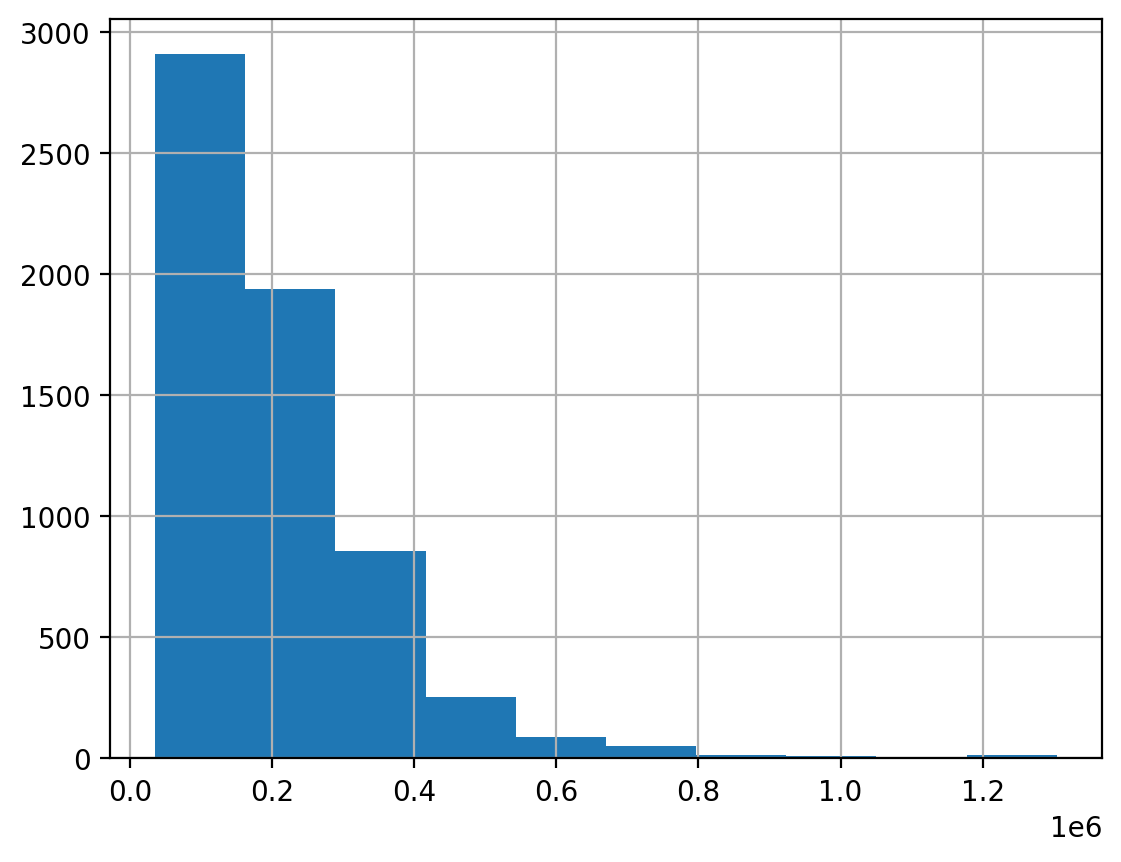

In [11]:
balt_sales.CONSIDR1.hist()

<Axes: ylabel='Density'>

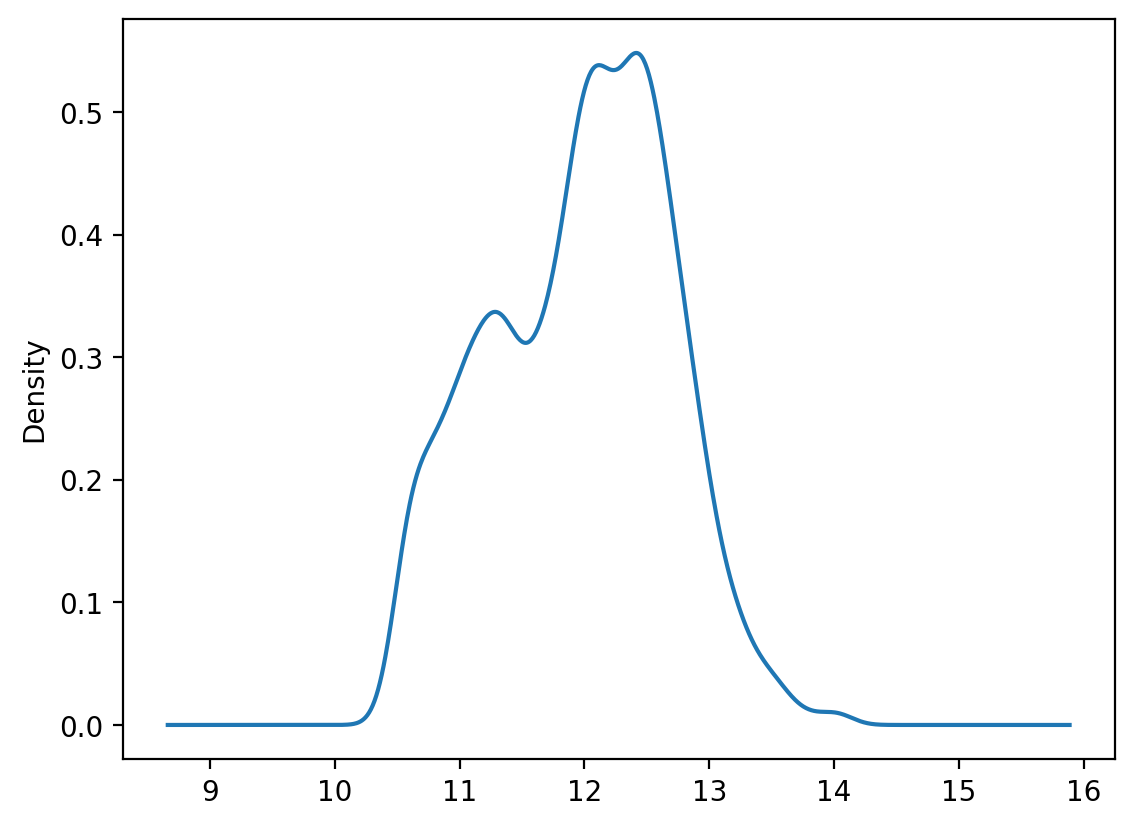

In [12]:
balt_sales.CONSIDR1.apply(np.log).plot(kind='density')

<Axes: >

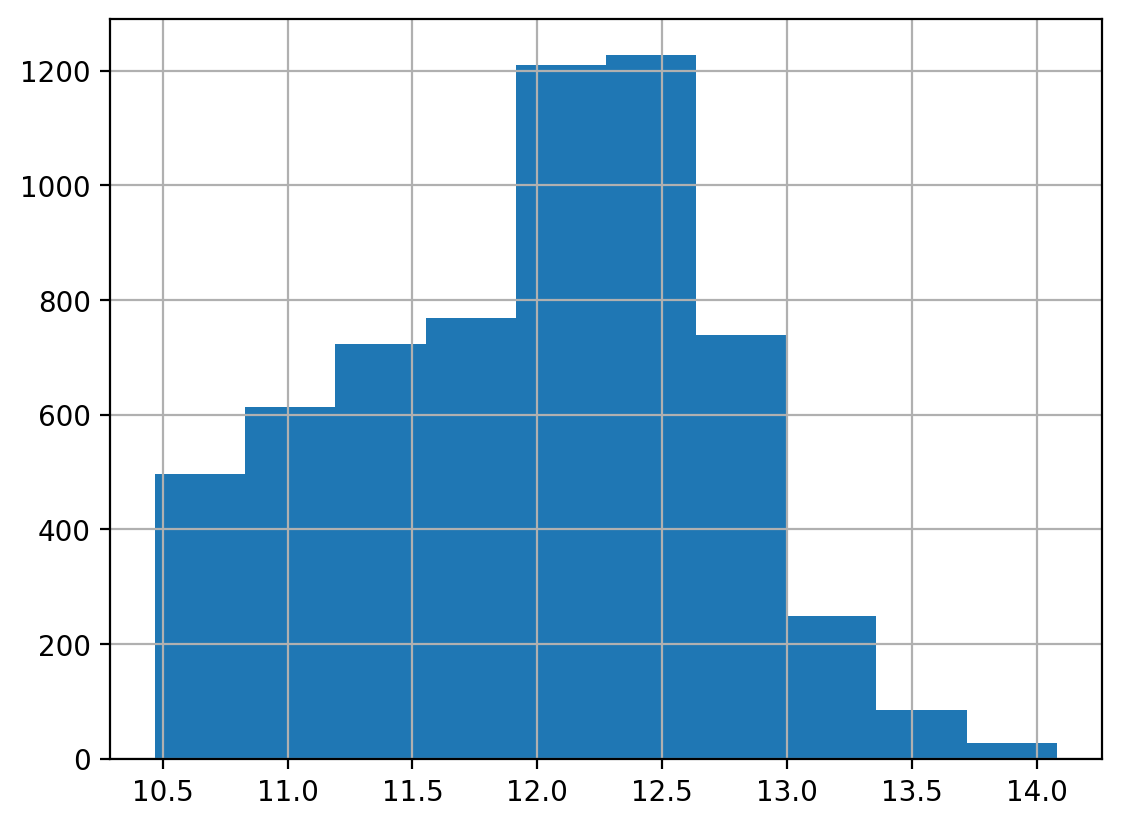

In [13]:
balt_sales.CONSIDR1.apply(np.log).hist()

In [14]:
balt_sales[['CONSIDR1', 'geometry']].explore('CONSIDR1', scheme='fisherjenks', tiles='cartodb darkmatter')

In [15]:
balt_sales.DESCBLDG

0          DWEL End Unit
1          DWEL End Unit
2       DWEL Center Unit
3       DWEL Center Unit
4       DWEL Center Unit
              ...       
6135    DWEL Center Unit
6136       DWEL End Unit
6137    DWEL Center Unit
6138    DWEL Center Unit
6139    DWEL Center Unit
Name: DESCBLDG, Length: 6140, dtype: category
Categories (6, object): ['DWEL Center Unit', 'DWEL End Unit', 'DWEL Rental Dwelling', 'DWEL Split Foyer', 'DWEL Split Level', 'DWEL Standard Unit']

In [16]:
balt_sales.DESCSTYL

0          STRY TH End 3 Story With Basement
1          STRY TH End 3 Story With Basement
2       STRY TH Center 3 Story With Basement
3       STRY TH Center 3 Story With Basement
4         STRY TH Center 2 Story No Basement
                        ...                 
6135    STRY TH Center 2 Story With Basement
6136       STRY TH End 2 Story With Basement
6137    STRY TH Center 2 Story With Basement
6138    STRY TH Center 2 Story With Basement
6139    STRY TH Center 2 Story With Basement
Name: DESCSTYL, Length: 6140, dtype: object

In [17]:
balt_sales.DESCSTYL.unique()

array(['STRY TH End 3 Story With Basement',
       'STRY TH Center 3 Story With Basement',
       'STRY TH Center 2 Story No Basement',
       'STRY TH Center 2 Story With Basement',
       'STRY TH End 2 Story With Basement',
       'STRY TH End 2 Story No Basement',
       'STRY TH End 3 Story No Basement',
       'STRY TH Center 3 Story No Basement', 'STRY 2 Story No Basement',
       'STRY TH Center 4 Story No Basement',
       'STRY TH End 2 1/2 Story With Basement',
       'STRY TH End 4 Story No Basement',
       'STRY TH Center 2 1/2 Story With Basement',
       'STRY TH Center 2 1/2 Story No Basement',
       'STRY 3 Story With Basement', 'STRY 2 Story With Basement',
       'STRY 1 Story With Basement', 'STRY 2 1/2 Story With Basement',
       'STRY TH End 1 Story No Basement',
       'STRY TH End 4 Story With Basement',
       'STRY TH Center 4 Story With Basement',
       'STRY 2 1/2 Story No Basement',
       'STRY TH End 2 1/2 Story No Basement',
       'STRY 1 1/2 Story 

In [18]:
balt_sales.DESCGRAD

0       Codes range from lowest to highest quality 1-9
1       Codes range from lowest to highest quality 1-9
2       Codes range from lowest to highest quality 1-9
3       Codes range from lowest to highest quality 1-9
4       Codes range from lowest to highest quality 1-9
                             ...                      
6135    Codes range from lowest to highest quality 1-9
6136    Codes range from lowest to highest quality 1-9
6137    Codes range from lowest to highest quality 1-9
6138    Codes range from lowest to highest quality 1-9
6139    Codes range from lowest to highest quality 1-9
Name: DESCGRAD, Length: 6140, dtype: object

In [19]:
balt_sales.STRUGRAD

0       3.0
1       6.0
2       3.0
3       3.0
4       6.0
       ... 
6135    3.0
6136    3.0
6137    3.0
6138    3.0
6139    3.0
Name: STRUGRAD, Length: 6140, dtype: float64

<Axes: ylabel='Frequency'>

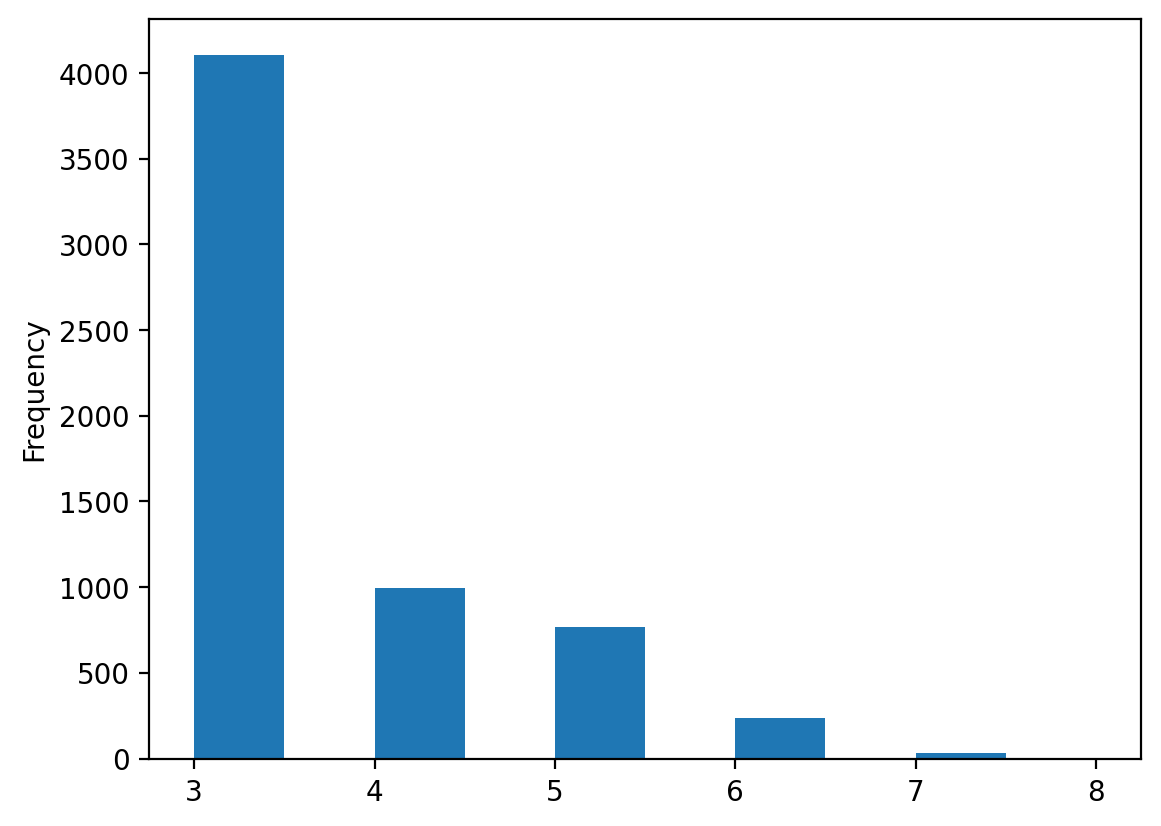

In [20]:
balt_sales.STRUGRAD.plot(kind='hist')

## Modeling Housing Characteristics

In [21]:
balt_sales['log_price'] = np.log(balt_sales.CONSIDR1)

In [22]:
mod = "log_price ~ STRUGRAD + DESCSTYL + SQFTSTRC + LANDAREA + ZONING"

In [23]:
mod1 = smf.ols(mod, data=balt_sales).fit()

In [24]:
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     78.90
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:04:52   Log-Likelihood:                -4833.8
No. Observations:                6127   AIC:                             9798.
Df Residuals:                    6062   BIC:                         1.023e+04
Df Model:                          64                                         
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
Intercept                                               10.5569      0.280     37.644      0.000      10.007      11.107
DESCSTYL[T.STRY 1 1/2 Story With Basement]              -0.1112      0.269     -0.413      0.679      -0.639       0.416
DESCSTYL[T.STRY 1 Story No Basement]                    -0.2774      0.318     -0.873      0.383      -0.900       0.346
DESCSTYL[T.STRY 1 Story With Basement]                  -0.1094      0.272     -0.403      0.687      -0.642       0.423
DESCSTYL[T.STRY 2 1/2 Story No Basement]                 0.2792      0.414      0.675      0.500      -0.532       1.090
DESCSTYL[T.STRY 2 1/2 Story With Basement]              -0.2409      0.272     -0.886      0.375      -0.773       0.292
DESCSTYL[T.STRY 2 Story No Basement]                     0.0616      0.283      0.218      0.828      -0.494       0.617
DESCSTYL[T.STRY 2 Story With Basement]                  -0.1587      0.269     -0.590      0.555      -0.686       0.369
DESCSTYL[T.STRY 3 Story No Basement]                    -0.3225      0.385     -0.839      0.402      -1.076       0.431
DESCSTYL[T.STRY 3 Story With Basement]                  -0.6789      0.311     -2.185      0.029      -1.288      -0.070
DESCSTYL[T.STRY Split Foyer]                             0.3141      0.346      0.907      0.365      -0.365       0.993
DESCSTYL[T.STRY TH Center 2 1/2 Story No Basement]      -0.0810      0.338     -0.240      0.811      -0.744       0.582
DESCSTYL[T.STRY TH Center 2 1/2 Story With Basement]     0.0411      0.293      0.140      0.888      -0.533       0.616
DESCSTYL[T.STRY TH Center 2 Story No Basement]          -0.0272      0.277     -0.098      0.922      -0.570       0.516
DESCSTYL[T.STRY TH Center 2 Story With Basement]        -0.0163      0.271     -0.060      0.952      -0.547       0.514
DESCSTYL[T.STRY TH Center 3 Story No Basement]           0.1106      0.277      0.400      0.689      -0.432       0.653
DESCSTYL[T.STRY TH Center 3 Story With Basement]         0.0488      0.273      0.179      0.858      -0.486       0.584
DESCSTYL[T.STRY TH Center 4 Story No Basement]           0.2785      0.387      0.721      0.471      -0.479       1.036
DESCSTYL[T.STRY TH Center 4 Story With Basement]         0.3719      0.474      0.785      0.432      -0.557       1.301
DESCSTYL[T.STRY TH End 1 1/2 Story With Basement]        0.0289      0.412      0.070      0.944      -0.778       0.836
DESCSTYL[T.STRY TH End 1 Story No Basement]             -0.4986      0.467     -1.069      0.285      -1.413       0.416
DESCSTYL[T.STRY TH End 1 Story With Basement]           -0.6800      0.348     -1.957      0.050      -1.361       0.001
DESCSTYL[T.STRY TH End 2 1/2 Story No Basement]         -0

In [25]:
mod1.resid

0      -0.156943
1       0.148820
2       0.070147
3       0.559532
4      -0.248006
          ...   
6135   -0.372430
6136    0.355850
6137    0.219687
6138   -0.022825
6139    0.010829
Length: 6127, dtype: float64

<Axes: >

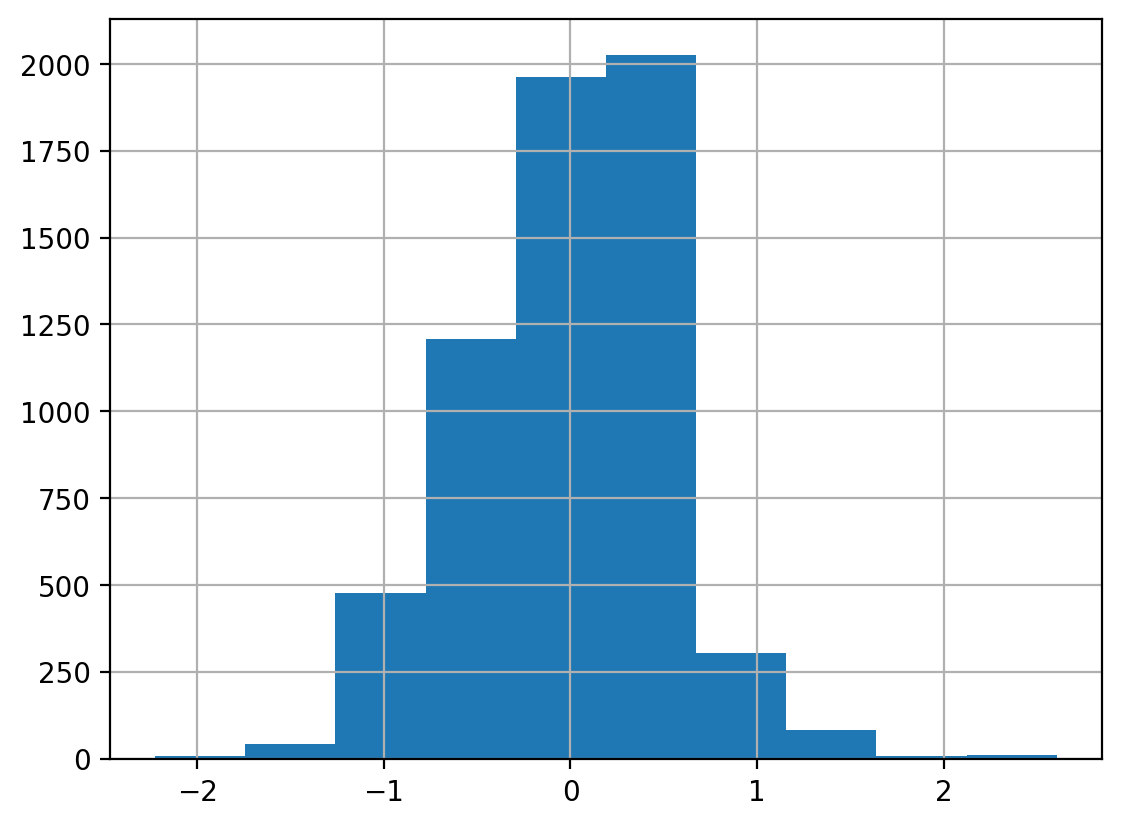

In [26]:
mod1.resid.hist()

In [27]:
from statsmodels.graphics.gofplots import qqplot

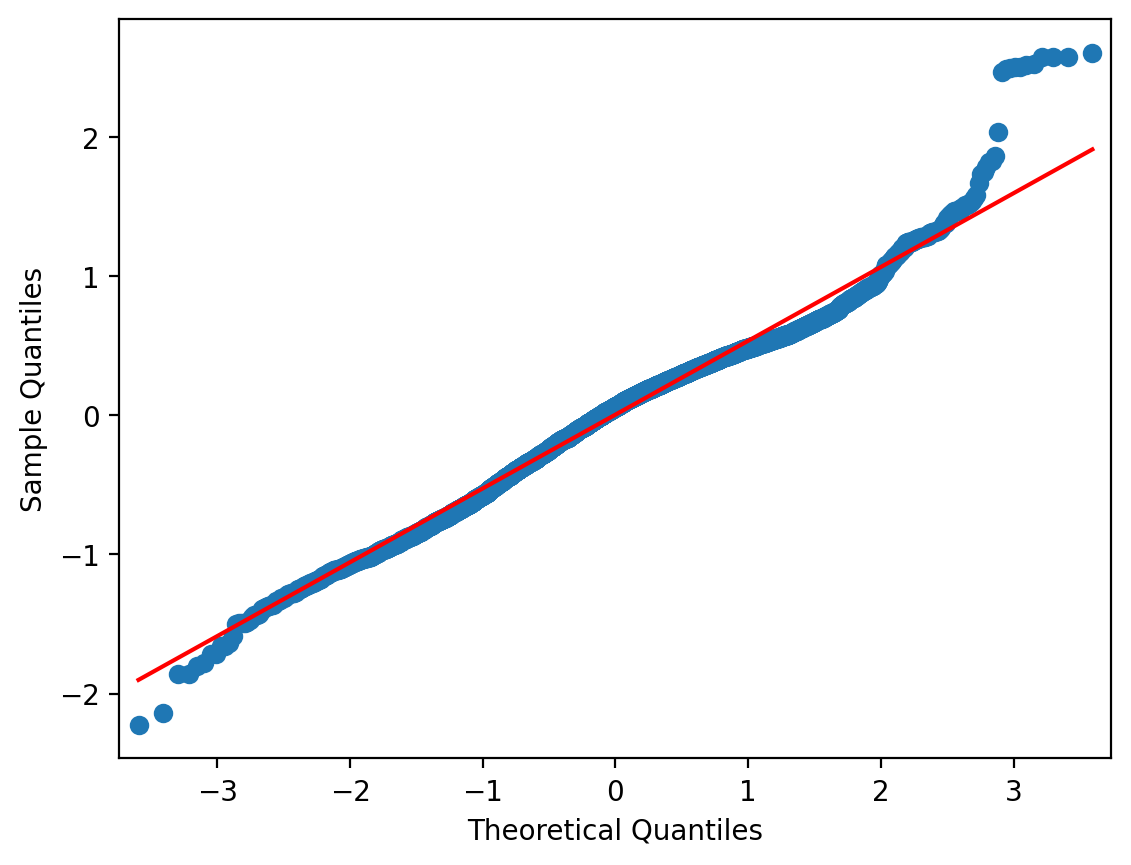

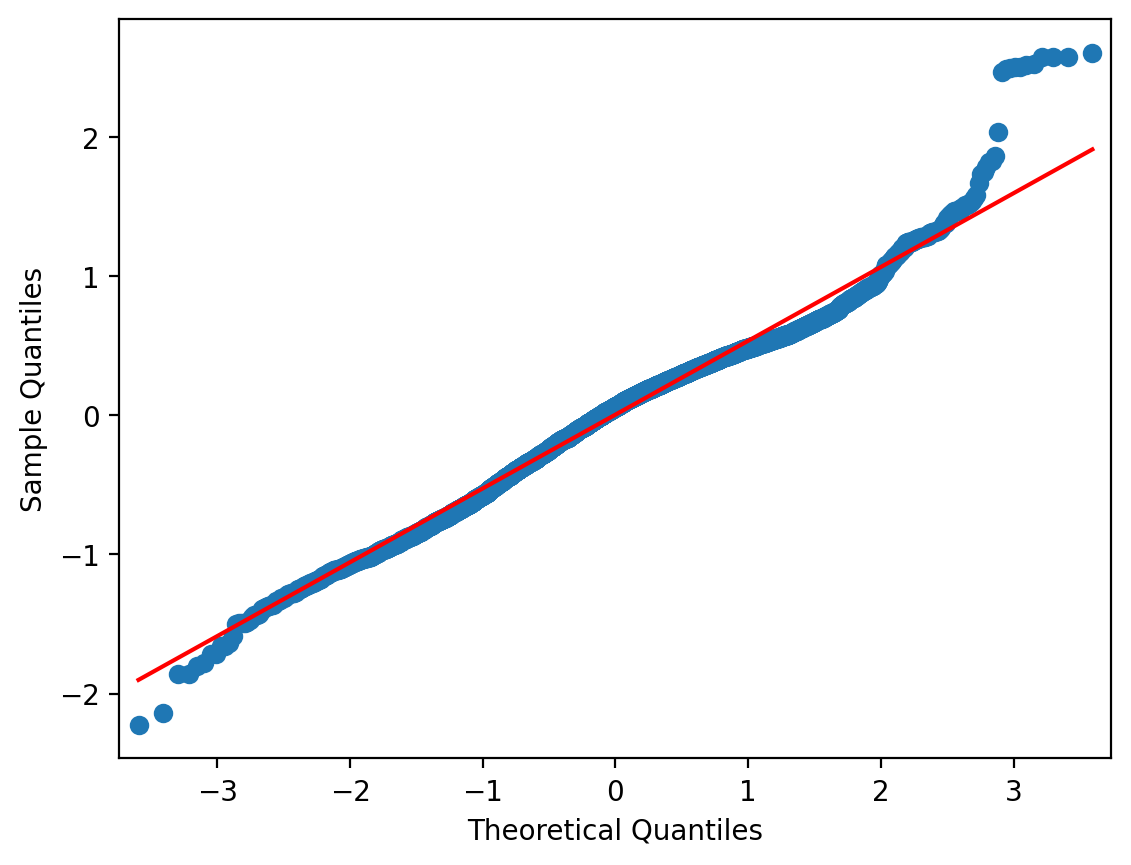

In [28]:
qqplot(mod1.resid, line='q')

## Modeling Housing & Neighborhood